# **CANCER**

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.feature_selection import RFECV

import xgboost as xgb
from xgboost import cv, DMatrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score

## **EDA**

In [94]:
import pandas as pd
data = pd.read_csv("../Data/survey lung cancer.csv")
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
# # ENCODE GENDER
# # Misalkan data Anda dalam DataFrame bernama df
# data['GENDER'] = data['GENDER'].apply(lambda x: 1 if x == 'M' else 0)
# data['LUNG_CANCER'] = data['LUNG_CANCER'].apply(lambda x: 1 if x == 'YES' else 0)

In [97]:
from sklearn.preprocessing import LabelEncoder

# Misalkan kolom 'gender' adalah kolom kategorikal
label_encoder = LabelEncoder()
data['GENDER'] = label_encoder.fit_transform(data['GENDER'])
data['LUNG_CANCER'] = label_encoder.fit_transform(data['LUNG_CANCER'])


In [98]:
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.isnull().sum()

In [ ]:
data.duplicated().sum()

In [99]:
data = data.drop_duplicates()

In [100]:
data.duplicated().sum()

0

In [ ]:
data.hist(figsize=(20,20))
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=[12,10])
sns.heatmap(data.corr(), annot= True)
plt.show()

In [101]:
##Menyeleksi variabel (feature selection)
X = data.drop(["LUNG_CANCER"], axis = 1)
y = data["LUNG_CANCER"]

estimator = RandomForestClassifier(max_depth=10,min_samples_split=100)
rfecv = RFECV(estimator=estimator, cv=StratifiedKFold(10, random_state=42, shuffle=True), scoring="accuracy")
rfecv.fit(X, y)

RFECV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
      estimator=RandomForestClassifier(max_depth=10, min_samples_split=100),
      scoring='accuracy')

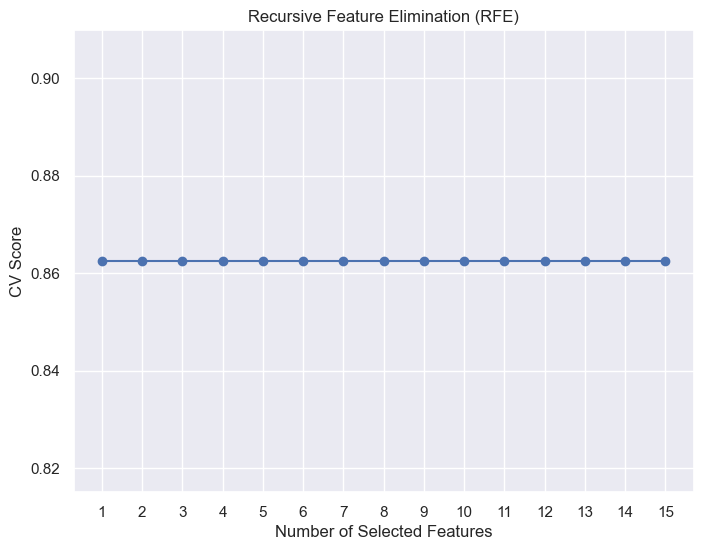

The optimal number of features: 1


In [102]:
##Plot RFE
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o')
plt.xticks(range(1, X.shape[1] + 1))
plt.xlabel("Number of Selected Features")
plt.ylabel("CV Score")
plt.title("Recursive Feature Elimination (RFE)")
plt.show()

print("The optimal number of features: {}".format(rfecv.n_features_))

In [103]:
##Prediktor terpilih
selected_features = X.columns[rfecv.support_]
X_selected = X[selected_features]

In [104]:
selected_features

Index(['ALLERGY '], dtype='object')

In [ ]:
data['ALLERGY '].head()

In [ ]:
data['FATIGUE '].head()

In [ ]:
# FIX FEATURE SELECTION

data_x= data[['AGE', "SMOKING", "YELLOW_FINGERS", "PEER_PRESSURE", "CHRONIC DISEASE", "ALCOHOL CONSUMING", "COUGHING", "SWALLOWING DIFFICULTY", "CHEST PAIN"]]
data_y = data['LUNG_CANCER']

## MODELLING CLASS WEIGHT

In [105]:
from sklearn.preprocessing import MinMaxScaler
ms_X = MinMaxScaler()

In [ ]:
data.columns

In [106]:
X = pd.DataFrame(ms_X.fit_transform(data[['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']]))
y = data['LUNG_CANCER']

In [107]:
import joblib
joblib.dump(ms_X, "./Output_Model/scaler_cancer.pkl")

['./Output_Model/scaler_cancer.pkl']

In [ ]:
# bagi data

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

In [ ]:
ratio

In [ ]:
import seaborn as sns
sns.histplot(data['LUNG_CANCER'])

In [117]:
import xgboost as xgb
xg = xgb.XGBClassifier(n_estimators = 100, scale_pos_weight=ratio)
xg.fit(X_train, y_train)
xg_preds= xg.predict(X_test)
print(classification_report(y_test, xg_preds))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.98      0.95      0.97        44

    accuracy                           0.95        56
   macro avg       0.91      0.94      0.92        56
weighted avg       0.95      0.95      0.95        56



In [116]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.42      0.59        12
           1       0.86      1.00      0.93        44

    accuracy                           0.88        56
   macro avg       0.93      0.71      0.76        56
weighted avg       0.89      0.88      0.85        56



In [108]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# Membuat model Decision Tree untuk klasifikasi
dt_clf = DecisionTreeClassifier(random_state=42)

# Melatih model
dt_clf.fit(X_train, y_train)

# Melakukan prediksi
y_pred = dt_clf.predict(X_test)

# Menampilkan laporan klasifikasi
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.90      0.98      0.93        44

    accuracy                           0.89        56
   macro avg       0.89      0.78      0.82        56
weighted avg       0.89      0.89      0.88        56



In [109]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])
# Membuat model Decision Tree untuk klasifikasi
dt_clf = DecisionTreeClassifier(random_state=42)

# Evaluasi menggunakan cross-validation dengan AUC sebagai skor
for cv in [3, 5, 10]:
    scores = cross_val_score(dt_clf, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"Cross-validation dengan cv={cv}")
    print(f"AUC pada setiap fold: {scores}")
    print(f"Rata-rata AUC: {scores.mean():.4f}")
    print("-" * 30)

# Melatih model pada data training
dt_clf.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred = dt_clf.predict(X_test)

# Menampilkan laporan klasifikasi
print("Laporan Klasifikasi pada Data Testing:")
print(classification_report(y_test, y_pred))


Cross-validation dengan cv=3
AUC pada setiap fold: [0.56495726 0.68846154 0.72309028]
Rata-rata AUC: 0.6588
------------------------------
Cross-validation dengan cv=5
AUC pada setiap fold: [0.58717949 0.64871795 0.66153846 0.61025641 0.80701754]
Rata-rata AUC: 0.6629
------------------------------
Cross-validation dengan cv=10
AUC pada setiap fold: [0.475      0.675      0.45       0.75       0.42105263 0.94736842
 0.75438596 0.72807018 0.78070175 0.64035088]
Rata-rata AUC: 0.6622
------------------------------
Laporan Klasifikasi pada Data Testing:
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.90      0.98      0.93        44

    accuracy                           0.89        56
   macro avg       0.89      0.78      0.82        56
weighted avg       0.89      0.89      0.88        56



Confusion Matrix:
[[ 7  5]
 [ 1 43]]


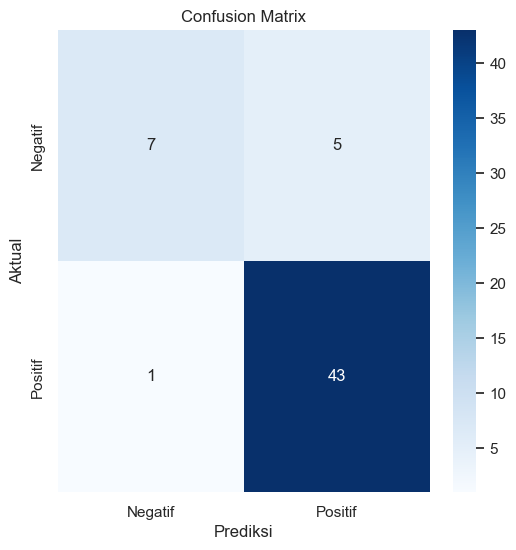

In [110]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Menampilkan confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualisasi confusion matrix dengan heatmap
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


Confusion Matrix (Persentase):
[[58.33333333 41.66666667]
 [ 2.27272727 97.72727273]]


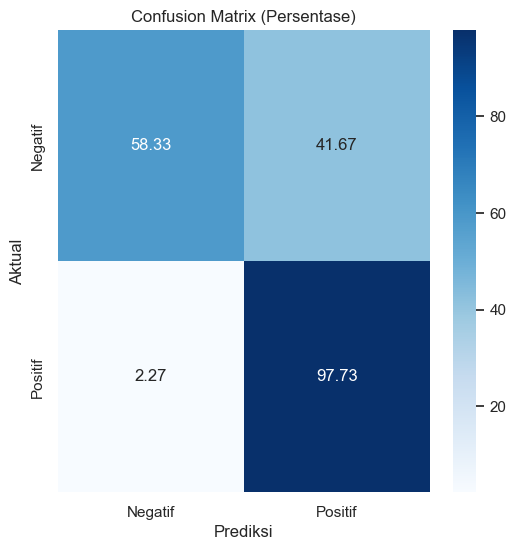

In [111]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Menghitung persentase untuk setiap elemen di confusion matrix
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Menampilkan confusion matrix dengan persentase
print("Confusion Matrix (Persentase):")
print(cm_percentage)

# Visualisasi confusion matrix dengan heatmap
plt.figure(figsize=(6,6))
sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix (Persentase)')
plt.show()


In [112]:
import joblib

# Tentukan path dan nama file untuk menyimpan model
model_path = "./Output_Model/cancer_DT.pkl"
# Simpan model
joblib.dump(dt_clf, model_path)
print(f"Model saved to {model_path}")

Model saved to ./Output_Model/cancer_DT.pkl


In [114]:
#Gunakan model

import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Memuat model yang disimpan (sesuaikan nama file model)
model_path = "./Output_Model/cancer_DT.pkl" # Sesuaikan path model
model = joblib.load(model_path)

# Memuat data test tanpa kolom Y
data_test = pd.read_csv(r"D:\Lomba-Lomba\TSDN 2024\cancerno Y.csv")

sc_X = StandardScaler()
data_test = (sc_X.fit_transform(data_test))

In [115]:
# Melakukan prediksi
predictions = model.predict(data_test)

# Menampilkan atau menyimpan hasil prediksi
print(predictions)
pd.DataFrame(predictions, columns=['Predictions']).to_csv("predictions.csv", index=False)
print("Prediksi telah disimpan ke predictions.csv")

[1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1]
Prediksi telah disimpan ke predictions.csv
